# 1. মুখ শনাক্তকরণ কী (What is Face Recognition)

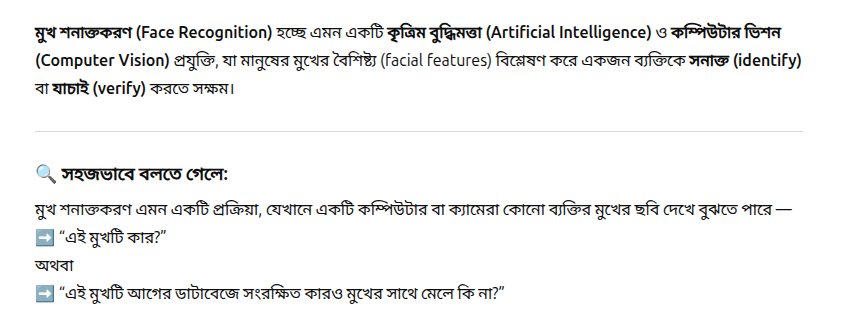

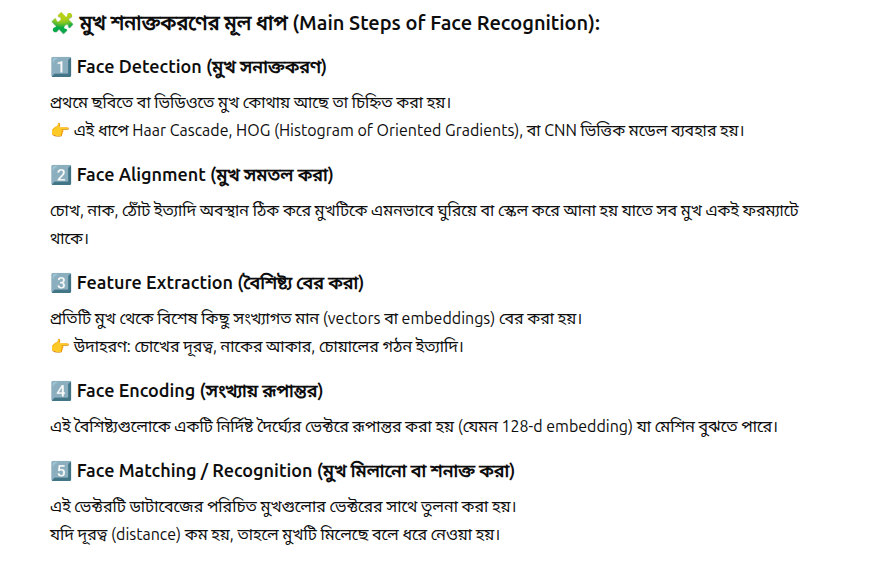

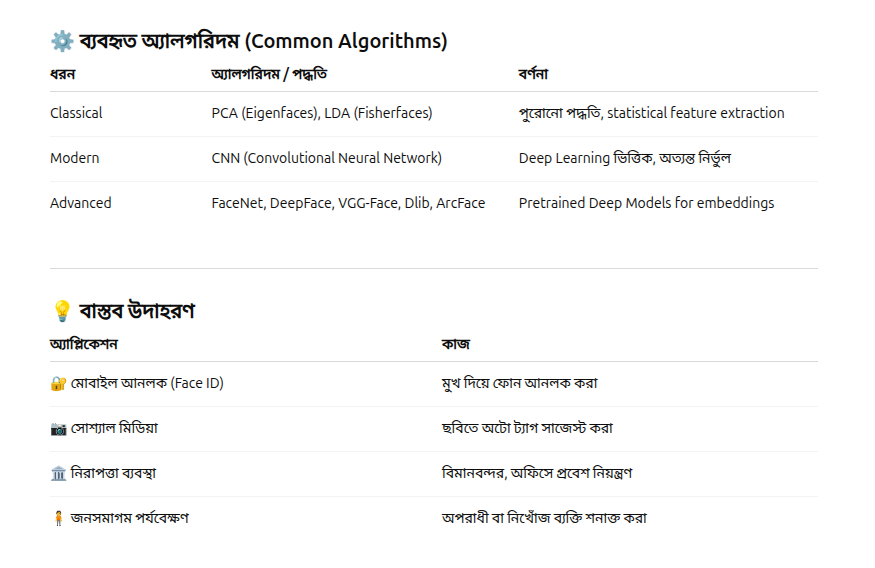

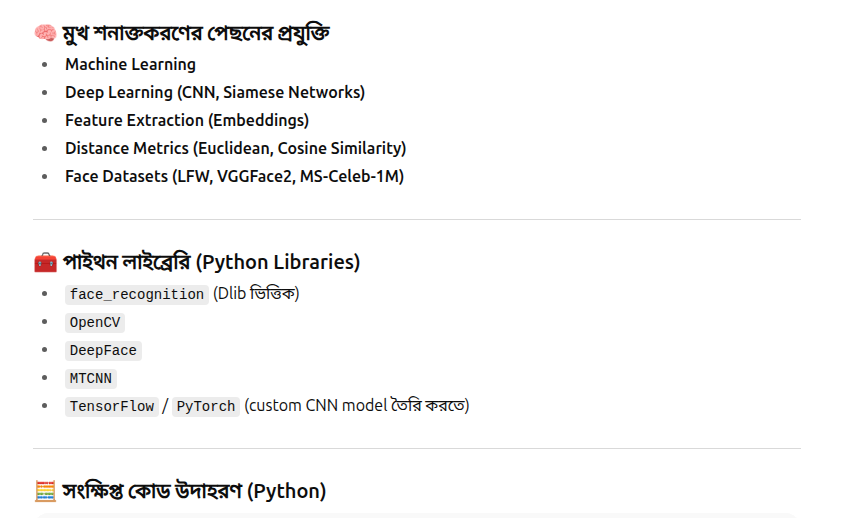

**i. Show the image using (Matplotlib + face_recognition)**

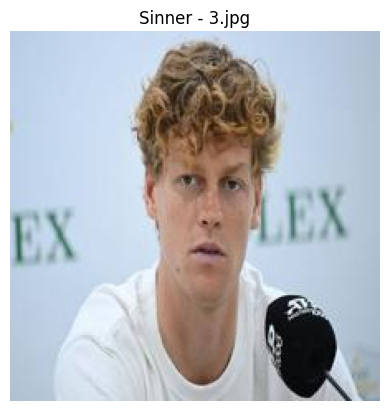

In [18]:
import face_recognition
import matplotlib.pyplot as plt

# Step 1: Load image (relative path)
image_path = "../dataset/train/sinner/3.jpg"
image = face_recognition.load_image_file(image_path)

# Step 2: Show image using matplotlib
plt.imshow(image)
plt.title("Sinner - 3.jpg")
plt.axis("off")   # hides axis numbers
plt.show()

**ii. Show the image using (Matplotlib + OpenCV)**

If you use OpenCV’s `cv2.imread()`, remember that it loads images in **BGR format**,
so you must convert it to **RGB** before displaying:

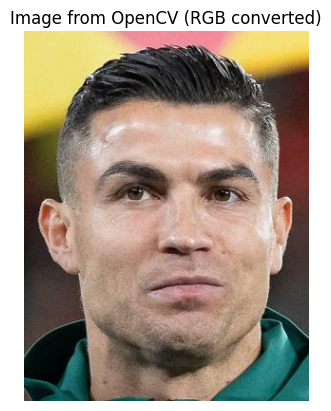

In [26]:
import cv2
import matplotlib.pyplot as plt

image_path = "../dataset/test/ronaldo.jpg"
img = cv2.imread(image_path)           # BGR format
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

plt.imshow(img_rgb)
plt.title("Image from OpenCV (RGB converted)")
plt.axis("off")
plt.show()

**iii. face**

In [20]:
import face_recognition
import matplotlib.pyplot as plt

In [21]:
# 1. পরিচিত মুখ লোড
known_image = face_recognition.load_image_file("../dataset/train/sinner/3.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]

In [22]:
# 2. অজানা মুখ লোড
unknown_image = face_recognition.load_image_file("../dataset/test/sinner.jpeg")
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

In [23]:
# 3. তুলনা
results = face_recognition.compare_faces([known_encoding], unknown_encoding)
print("Is same person:", results[0])

Is same person: True


**OR,**

In [24]:
# 2. অজানা মুখ লোড
unknown_image = face_recognition.load_image_file("../dataset/test/ronaldo.jpg")
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

In [25]:
# 3. তুলনা
results = face_recognition.compare_faces([known_encoding], unknown_encoding)
print("Is same person:", results[0])

Is same person: False


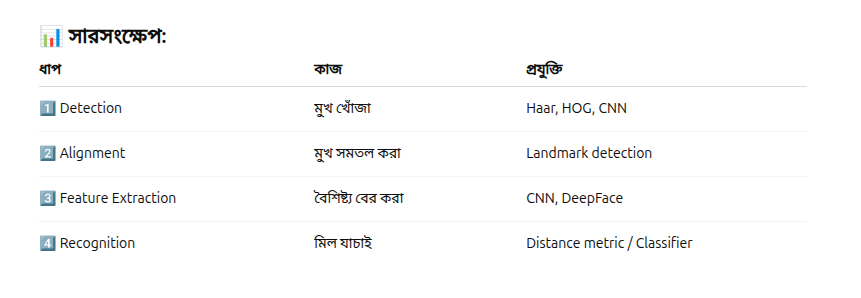

# 2. মুখ শনাক্তকরণ ও মুখ সনাক্তকরণের পার্থক্য (Recognition vs Detection)

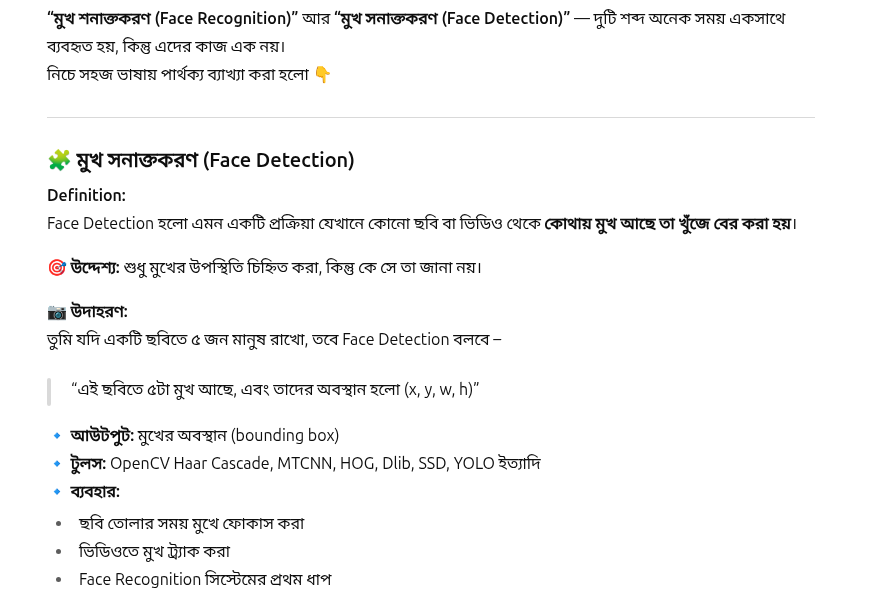

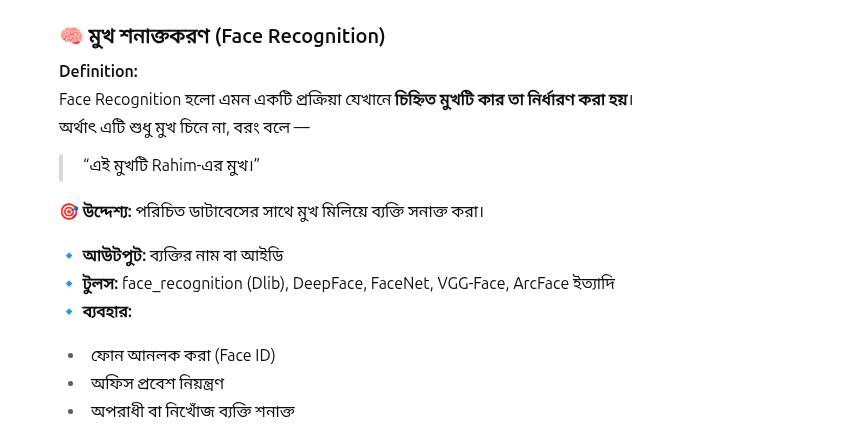

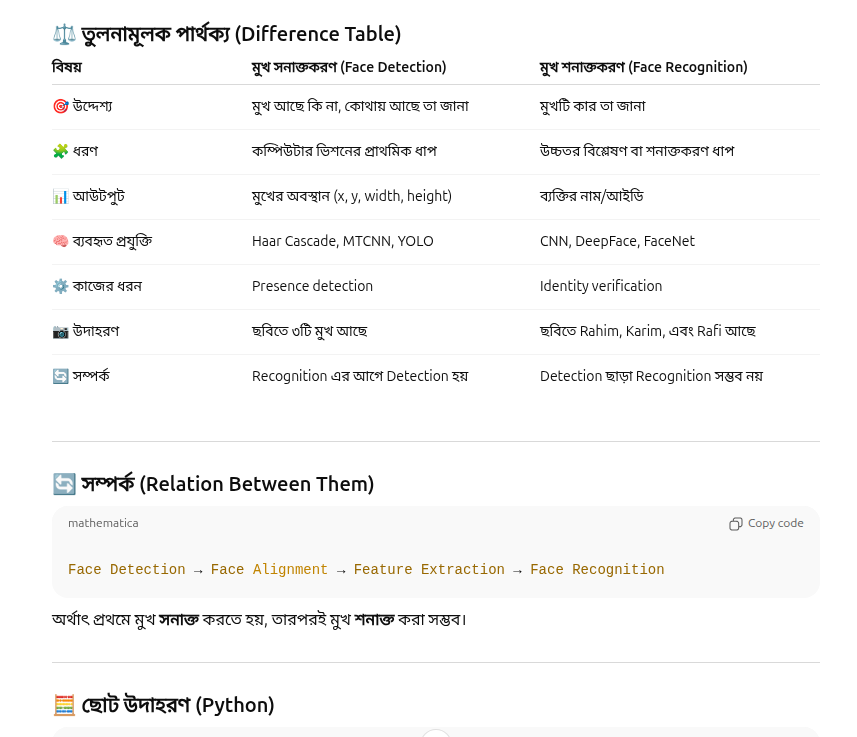

In [27]:
import face_recognition
import cv2

In [28]:
# ছবি লোড করা
image = face_recognition.load_image_file("../dataset/train/shelton/3.jpg")

In [29]:
# 1. Face Detection
face_locations = face_recognition.face_locations(image)
print(f"Total faces detected: {len(face_locations)}")

Total faces detected: 1


In [30]:
# 2. Face Recognition (পরিচিত মুখ মিলানো)
known_image = face_recognition.load_image_file("../dataset/test/sinner.jpeg")
known_encoding = face_recognition.face_encodings(known_image)[0]

In [33]:
unknown_encoding = face_recognition.face_encodings(image)[0]
results = face_recognition.compare_faces([known_encoding], unknown_encoding)

if results[0]:
    print("✅ The face matches Shelton.")
else:
    print("❌ The face does not match Shelton.")

❌ The face does not match Shelton.


**OR,**

In [34]:
# 2. Face Recognition (পরিচিত মুখ মিলানো)
known_image = face_recognition.load_image_file("../dataset/test/shelton.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]

In [35]:
unknown_encoding = face_recognition.face_encodings(image)[0]
results = face_recognition.compare_faces([known_encoding], unknown_encoding)

if results[0]:
    print("✅ The face matches Shelton.")
else:
    print("❌ The face does not match Shelton.")

✅ The face matches Shelton.


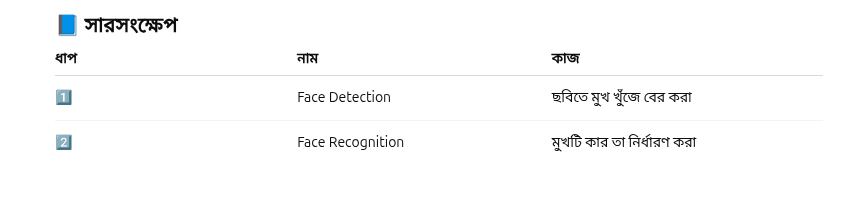

# 3. Face Detection vs Face Recognition vs Face Verification

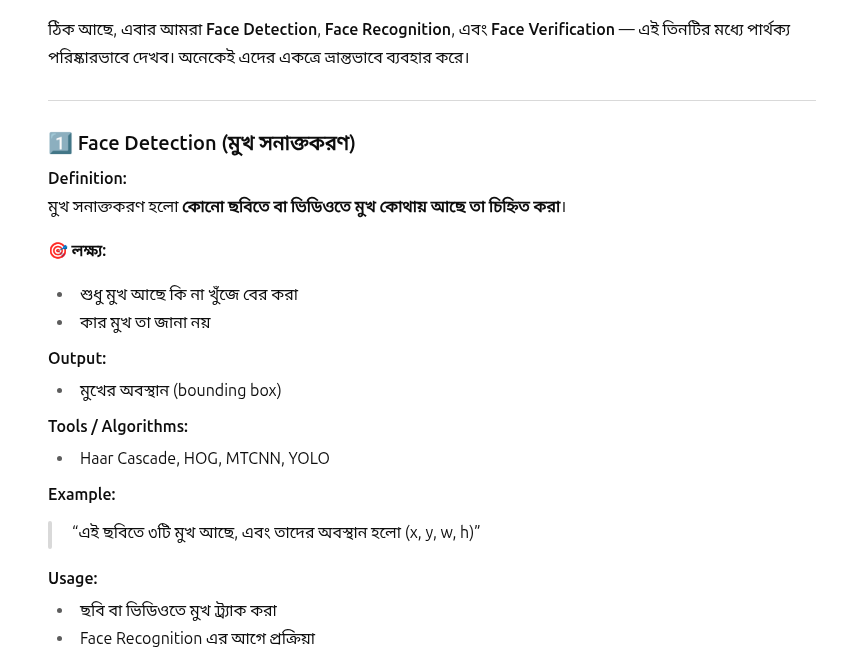

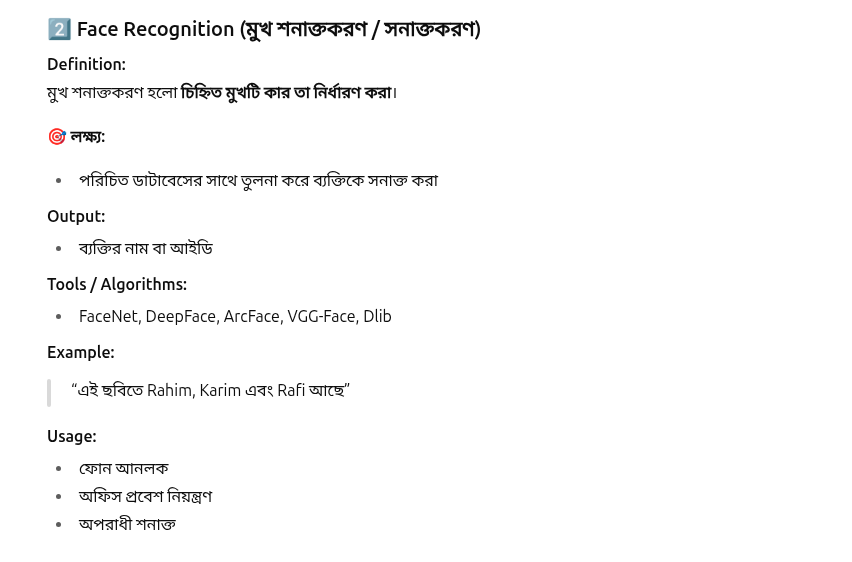

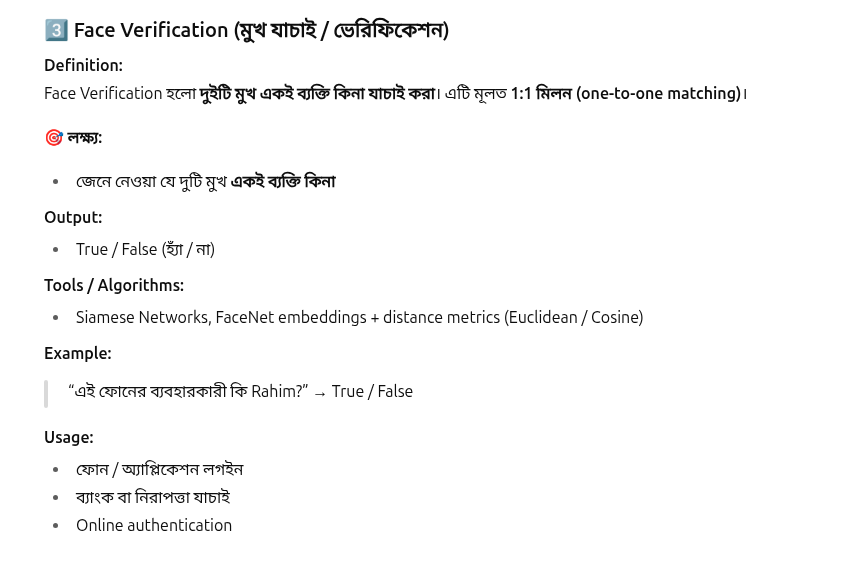

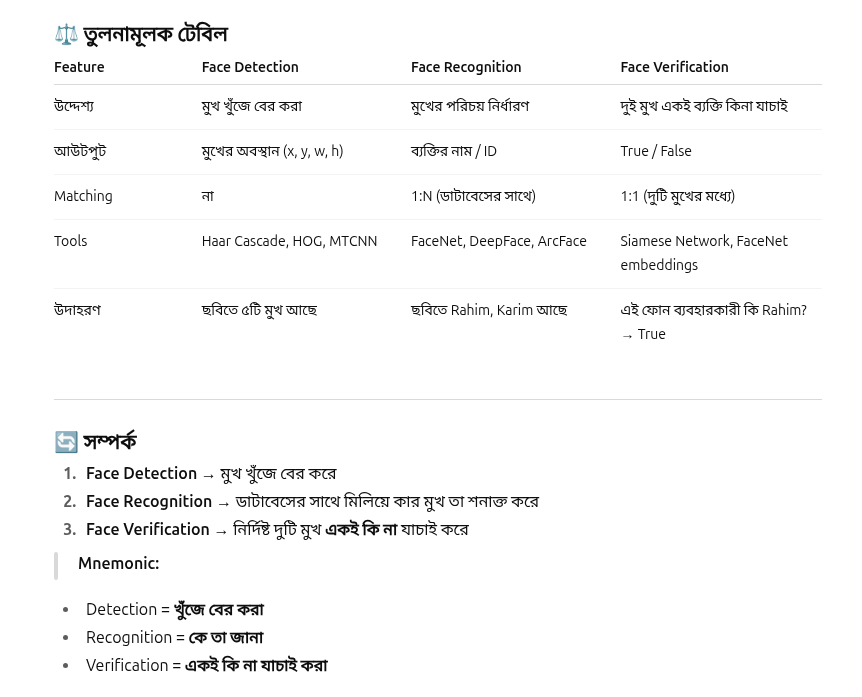

**Code : Detection + Recognition + Verification**

In [36]:
import face_recognition
import cv2
import numpy as np

In [38]:
# 1. পরিচিত মুখ লোড
known_image = face_recognition.load_image_file("../dataset/train/ronaldo/5.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]

# পরিচিত মুখের নাম
known_name = "Ronaldo"

In [39]:
# 2. অজানা মুখ লোড
unknown_image = face_recognition.load_image_file("../dataset/test/ronaldo.jpg")
unknown_encodings = face_recognition.face_encodings(unknown_image)

In [40]:
# 3. Face Detection
# ছবিতে মুখের অবস্থান
face_locations = face_recognition.face_locations(unknown_image)
print(f"Total faces detected: {len(face_locations)}")
print("Face locations (top, right, bottom, left):")
print(face_locations)

Total faces detected: 1
Face locations (top, right, bottom, left):
[(118, 266, 341, 43)]


In [41]:
# 4. Face Recognition & Verification
for unknown_encoding, location in zip(unknown_encodings, face_locations):
    
    # Face Recognition (1:N) → কোন পরিচিত মুখের সাথে মিলে?
    results = face_recognition.compare_faces([known_encoding], unknown_encoding)
    
    # Face Verification (1:1) → এই ছবি কি Ronaldo?
    distance = face_recognition.face_distance([known_encoding], unknown_encoding)[0]
    
    print("\nমুখের অবস্থান:", location)
    print("Recognition Result:", known_name if results[0] else "Unknown")
    print(f"Verification Distance: {distance:.2f}")
    
    # একটি থ্রেশহোল্ড ধরুন
    if distance < 0.6:
        print("Verification: ✅ Match (Same Person)")
    else:
        print("Verification: ❌ Not Match (Different Person)")


মুখের অবস্থান: (118, 266, 341, 43)
Recognition Result: Ronaldo
Verification Distance: 0.57
Verification: ✅ Match (Same Person)


In [42]:
# 5. Optionally OpenCV দিয়ে ছবি দেখানো
image = cv2.cvtColor(unknown_image, cv2.COLOR_RGB2BGR)
for (top, right, bottom, left), unknown_encoding in zip(face_locations, unknown_encodings):
    cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)
    label = known_name if face_recognition.compare_faces([known_encoding], unknown_encoding)[0] else "Unknown"
    cv2.putText(image, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

cv2.imshow("Result", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

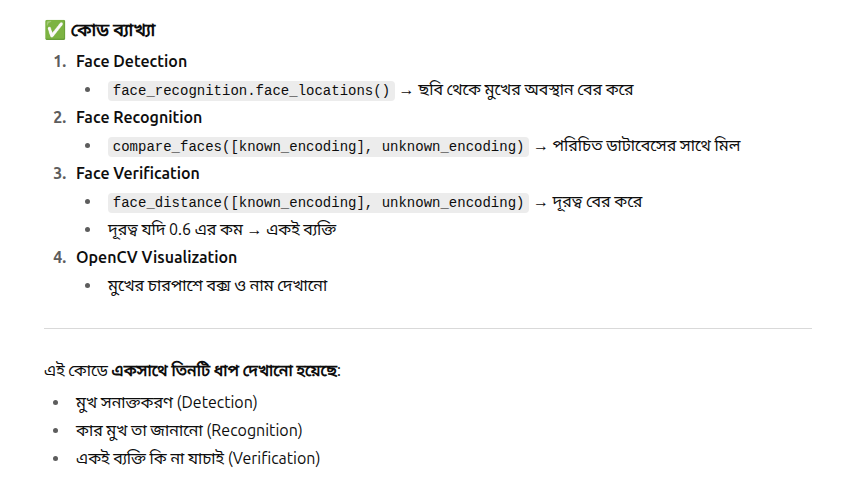

**i. Interactive Face Recognition**

In [47]:
import face_recognition
import cv2
import numpy as np


# 1. Load Known Face
known_image = face_recognition.load_image_file("../dataset/train/shelton/3.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]
known_name = "Shelton"


# 2. Ask User for Mode
print("Choose mode:")
print("1 - Image")
print("2 - Webcam")
print("3 - Video")
choice = input("Enter your choice (1/2/3): ")

if choice == "1":
    mode = "image"
elif choice == "2":
    mode = "webcam"
elif choice == "3":
    mode = "video"
else:
    print("❌ Invalid choice! Exiting...")
    exit()


# Optional: Video file path
video_path = "../dataset/vid/s.mp4"


# IMAGE MODE
if mode == "image":
    unknown_image = face_recognition.load_image_file("../dataset/test/shelton.jpg")
    face_locations = face_recognition.face_locations(unknown_image)
    face_encodings = face_recognition.face_encodings(unknown_image, face_locations)

    print(f"Total faces detected: {len(face_locations)}")

    # Recognition
    for encoding, location in zip(face_encodings, face_locations):
        results = face_recognition.compare_faces([known_encoding], encoding)
        distance = face_recognition.face_distance([known_encoding], encoding)[0]
        label = known_name if results[0] else "Unknown"
        print(f"Face at {location}: {label}, Distance: {distance:.2f}")

    # Draw boxes
    image = cv2.cvtColor(unknown_image, cv2.COLOR_RGB2BGR)
    for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
        label = known_name if face_recognition.compare_faces([known_encoding], encoding)[0] else "Unknown"
        color = (0,255,0) if label == known_name else (0,0,255)
        cv2.rectangle(image, (left, top), (right, bottom), color, 2)
        cv2.putText(image, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow("Image Result", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


# WEBCAM MODE
elif mode == "webcam":
    cap = cv2.VideoCapture(0)
    print("🎥 Webcam started — press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face_locations = face_recognition.face_locations(rgb_frame)
        face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

        for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
            results = face_recognition.compare_faces([known_encoding], encoding)
            distance = face_recognition.face_distance([known_encoding], encoding)[0]
            label = f"{known_name} ({distance:.2f})" if results[0] and distance < 0.6 else "Unknown"
            color = (0,255,0) if known_name in label else (0,0,255)

            cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
            cv2.putText(frame, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.imshow("Webcam Face Recognition", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


# # VIDEO MODE
# elif mode == "video":
#     cap = cv2.VideoCapture(video_path)
#     print(f"🎞️ Processing video: {video_path}")
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         face_locations = face_recognition.face_locations(rgb_frame)
#         face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

#         for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
#             results = face_recognition.compare_faces([known_encoding], encoding)
#             distance = face_recognition.face_distance([known_encoding], encoding)[0]
#             label = f"{known_name} ({distance:.2f})" if results[0] and distance < 0.6 else "Unknown"
#             color = (0,255,0) if known_name in label else (0,0,255)

#             cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
#             cv2.putText(frame, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

#         cv2.imshow("Video Face Recognition", frame)
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break
#     cap.release()
#     cv2.destroyAllWindows()

# Video Frame load First
# VIDEO MODE
elif mode == "video":
    cap = cv2.VideoCapture(video_path)
    print(f"🎞️ Processing video: {video_path}")
    
    process_every_n_frames = 2  # adjust for speed vs accuracy
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # 1️⃣ Resize for faster face detection
        small_frame = cv2.resize(frame, (0,0), fx=0.25, fy=0.25)
        rgb_small = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        face_locations = []
        face_encodings = []

        # 2️⃣ Process only every n frames
        if frame_count % process_every_n_frames == 0:
            face_locations = face_recognition.face_locations(rgb_small)
            face_encodings = face_recognition.face_encodings(rgb_small, face_locations)

        # 3️⃣ Draw boxes and labels
        for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
            results = face_recognition.compare_faces([known_encoding], encoding)
            distance = face_recognition.face_distance([known_encoding], encoding)[0]
            label = f"{known_name} ({distance:.2f})" if results[0] and distance < 0.6 else "Unknown"
            color = (0,255,0) if known_name in label else (0,0,255)

            # Scale coordinates back to original frame size
            top *= 4
            right *= 4
            bottom *= 4
            left *= 4

            cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
            cv2.putText(frame, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # 4️⃣ Show frame
        cv2.imshow("Video Face Recognition", frame)

        # Quit with 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Choose mode:
1 - Image
2 - Webcam
3 - Video


Enter your choice (1/2/3):  3


🎞️ Processing video: ../dataset/vid/s.mp4


**ii. Multi-Person Face Recognition Script**

In [3]:
import face_recognition
import cv2
import os
import numpy as np


# 1. Load Known Faces
known_dir = "../dataset/train/"
known_encodings = []
known_names = []

print("⏳ Loading known faces...\n")

total_images = 0

for person_name in os.listdir(known_dir):
    person_path = os.path.join(known_dir, person_name)
    if not os.path.isdir(person_path):
        continue

    # Count images in this folder
    images = [img for img in os.listdir(person_path) if os.path.isfile(os.path.join(person_path, img))]
    num_images = len(images)
    total_images += num_images

    print(f"Folder/Label: {person_name} → Total Images: {num_images}")

    # Load face encodings
    for image_name in images:
        image_path = os.path.join(person_path, image_name)
        image = face_recognition.load_image_file(image_path)
        encodings = face_recognition.face_encodings(image)
        if encodings:
            known_encodings.append(encodings[0])
            known_names.append(person_name)  # folder name as label

print(f"\n✅ Loaded {len(known_encodings)} faces from {len(os.listdir(known_dir))} folders.")
print(f"✅ Total images in all folders: {total_images}\n")

⏳ Loading known faces...

Folder/Label: trent → Total Images: 5
Folder/Label: costa → Total Images: 4
Folder/Label: fernandes → Total Images: 5
Folder/Label: dias → Total Images: 6
Folder/Label: kohli → Total Images: 5
Folder/Label: cancelo → Total Images: 6
Folder/Label: pickford → Total Images: 6
Folder/Label: sinner → Total Images: 3
Folder/Label: brozovic → Total Images: 5
Folder/Label: vitinha → Total Images: 5
Folder/Label: deligt → Total Images: 5
Folder/Label: messi → Total Images: 6
Folder/Label: bale → Total Images: 5
Folder/Label: pepe → Total Images: 5
Folder/Label: saka → Total Images: 4
Folder/Label: marcelo → Total Images: 5
Folder/Label: ozil → Total Images: 7
Folder/Label: bruyne → Total Images: 6
Folder/Label: casimiro → Total Images: 5
Folder/Label: mbappe → Total Images: 6
Folder/Label: ramos → Total Images: 6
Folder/Label: rodriguez → Total Images: 5
Folder/Label: shelton → Total Images: 3
Folder/Label: ronaldo → Total Images: 6
Folder/Label: mendes → Total Images:

In [7]:
# 2. IMAGE FOLDER MODE
test_dir = "../dataset/test/"
threshold = 0.50  # drawing threshold

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)
    unknown_image = face_recognition.load_image_file(img_path)
    face_locations = face_recognition.face_locations(unknown_image)
    face_encodings = face_recognition.face_encodings(unknown_image, face_locations)

    print(f"\nProcessing {img_name} - Total faces detected: {len(face_locations)}")

    image = cv2.cvtColor(unknown_image, cv2.COLOR_RGB2BGR)

    for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
        distances = face_recognition.face_distance(known_encodings, encoding)
        best_match_index = np.argmin(distances)

        # ✅ Print always the closest name
        print(f"Face at {(top, right, bottom, left)}: {known_names[best_match_index]}, Distance: {distances[best_match_index]:.2f}")

        # 🎨 Drawing logic
        if distances[best_match_index] < threshold:
            name_to_draw = known_names[best_match_index]  # Green box
            color = (0, 255, 0)
        else:
            name_to_draw = "Unknown"  # Red box
            color = (0, 0, 255)

        cv2.rectangle(image, (left, top), (right, bottom), color, 2)
        cv2.putText(image, f"{name_to_draw} ({distances[best_match_index]:.2f})",
                    (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow(f"Result - {img_name}", image)
    cv2.waitKey(0)

cv2.destroyAllWindows()


Processing salah.jpg - Total faces detected: 1
Face at (142, 825, 409, 557): ramos, Distance: 0.55

Processing ronaldo.jpg - Total faces detected: 1
Face at (118, 266, 341, 43): ronaldo, Distance: 0.34

Processing bellingham.jpg - Total faces detected: 1
Face at (82, 225, 211, 96): rodriguez, Distance: 0.65

Processing cummins.jpg - Total faces detected: 1
Face at (96, 354, 225, 225): cummins, Distance: 0.49

Processing sinner.jpeg - Total faces detected: 1
Face at (82, 483, 211, 354): sinner, Distance: 0.46

Processing shelton.jpg - Total faces detected: 1
Face at (162, 974, 547, 589): shelton, Distance: 0.32


In [ ]:
# 3. WEBCAM MODE

threshold = 0.50  # drawing threshold

cap = cv2.VideoCapture(0)
print("🎥 Webcam started — press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize for faster processing
    small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
    rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

    face_locations = face_recognition.face_locations(rgb_small_frame)
    face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)

    for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
        distances = face_recognition.face_distance(known_encodings, encoding)
        best_match_index = np.argmin(distances)

        # ✅ Print always closest name
        print(f"Face at {(top*4, right*4, bottom*4, left*4)}: {known_names[best_match_index]}, Distance: {distances[best_match_index]:.2f}")

        # 🎨 Drawing logic
        if distances[best_match_index] < threshold:
            name_to_draw = known_names[best_match_index]  # Green box
            color = (0, 255, 0)
        else:
            name_to_draw = "Unknown"  # Red box
            color = (0, 0, 255)

        # Scale back up coordinates
        top *= 4
        right *= 4
        bottom *= 4
        left *= 4

        cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
        cv2.putText(frame, f"{name_to_draw} ({distances[best_match_index]:.2f})",
                    (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Webcam Face Recognition", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [11]:
# Video Mode 

# Video path
video_path = "../dataset/vid/s.mp4"

# Known encodings and names (assume loaded already)
# Example: known_encodings = [...], known_names = [...]

threshold = 0.65  # Drawing threshold

cap = cv2.VideoCapture(video_path)
print(f"🎞️ Processing video: {video_path} — press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize for faster processing
    small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
    rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

    face_locations = face_recognition.face_locations(rgb_small_frame)
    face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)

    for (top, right, bottom, left), encoding in zip(face_locations, face_encodings):
        distances = face_recognition.face_distance(known_encodings, encoding)
        best_match_index = np.argmin(distances)

        # ✅ Print always closest name
        print(f"Face at {(top*4, right*4, bottom*4, left*4)}: {known_names[best_match_index]}, Distance: {distances[best_match_index]:.2f}")

        # 🎨 Drawing logic
        if distances[best_match_index] < threshold:
            name_to_draw = known_names[best_match_index]  # Green box
            color = (0, 255, 0)
        else:
            name_to_draw = "Unknown"  # Red box
            color = (0, 0, 255)

        # Scale back up coordinates
        top *= 4
        right *= 4
        bottom *= 4
        left *= 4

        cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
        cv2.putText(frame, f"{name_to_draw} ({distances[best_match_index]:.2f})",
                    (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Video Face Recognition", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🎞️ Processing video: ../dataset/vid/s.mp4 — press 'q' to quit.
Face at (260, 544, 432, 372): shelton, Distance: 0.54
Face at (280, 544, 452, 372): shelton, Distance: 0.52
Face at (280, 544, 452, 372): shelton, Distance: 0.48
Face at (280, 544, 452, 372): shelton, Distance: 0.53
Face at (280, 544, 452, 372): shelton, Distance: 0.56
Face at (280, 564, 452, 392): shelton, Distance: 0.52
Face at (312, 564, 456, 420): shelton, Distance: 0.55
Face at (296, 564, 472, 392): shelton, Distance: 0.54
Face at (296, 564, 472, 392): shelton, Distance: 0.57
Face at (312, 548, 456, 404): shelton, Distance: 0.55
Face at (312, 548, 456, 404): sinner, Distance: 0.56
Face at (312, 548, 456, 404): ronaldo, Distance: 0.55
Face at (248, 564, 392, 420): ramos, Distance: 0.52
Face at (248, 564, 392, 420): shelton, Distance: 0.56
Face at (248, 564, 392, 420): ramos, Distance: 0.52
Face at (232, 564, 376, 420): ozil, Distance: 0.53
Face at (232, 564, 376, 420): sinner, Distance: 0.52
Face at (264, 596, 408, 452)

# 4. মুখ শনাক্তকরণের অ্যাপ্লিকেশন (Applications)

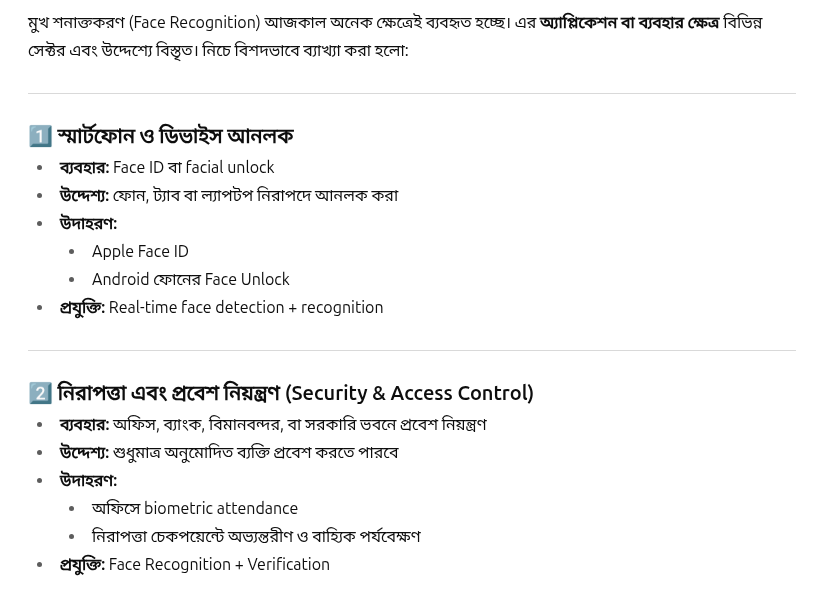

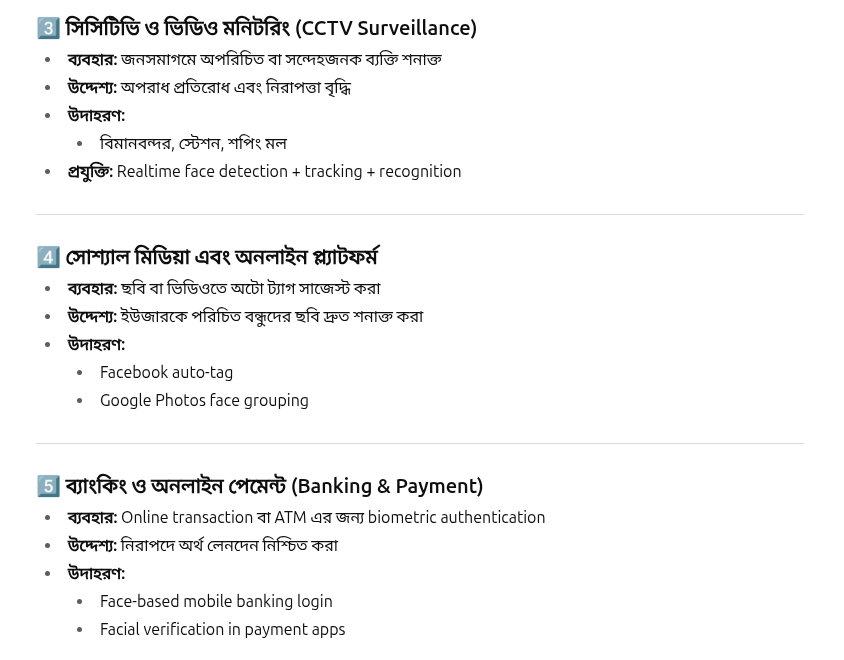

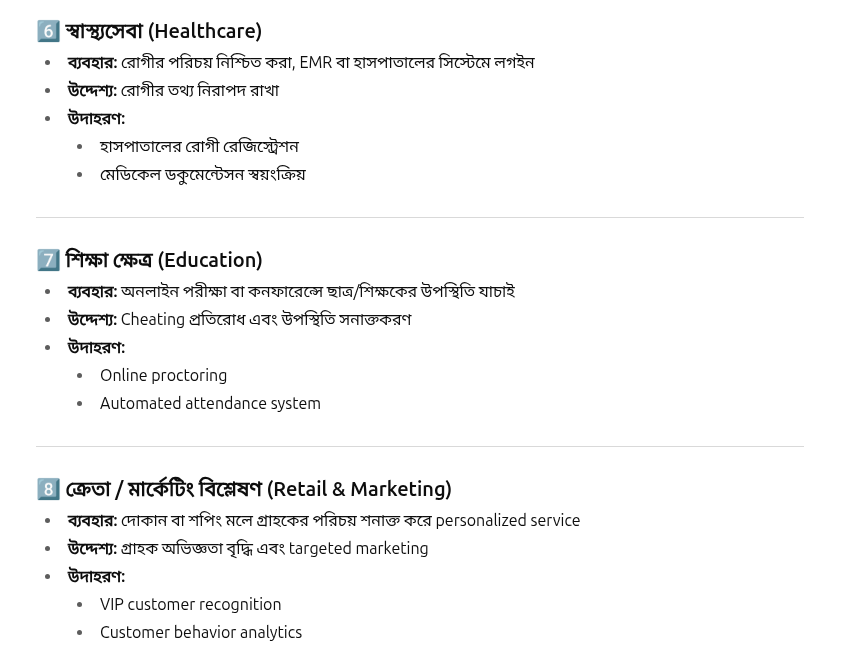

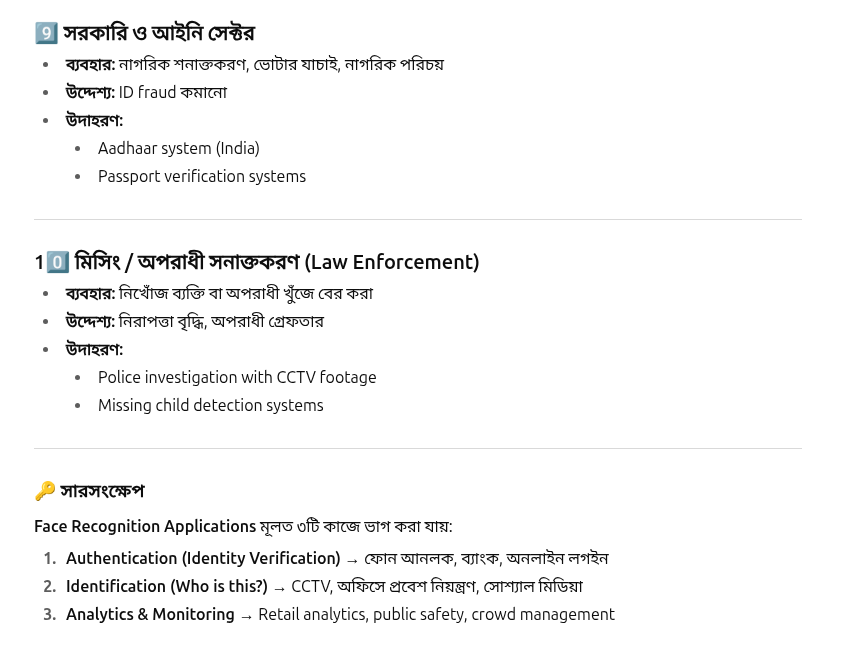

# 5. মুখ শনাক্তকরণের ধাপসমূহ (Pipeline Overview)

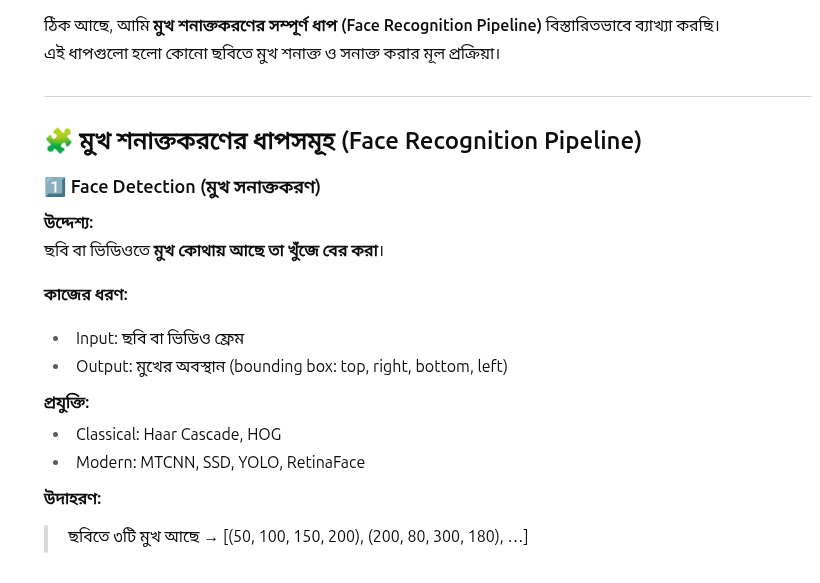

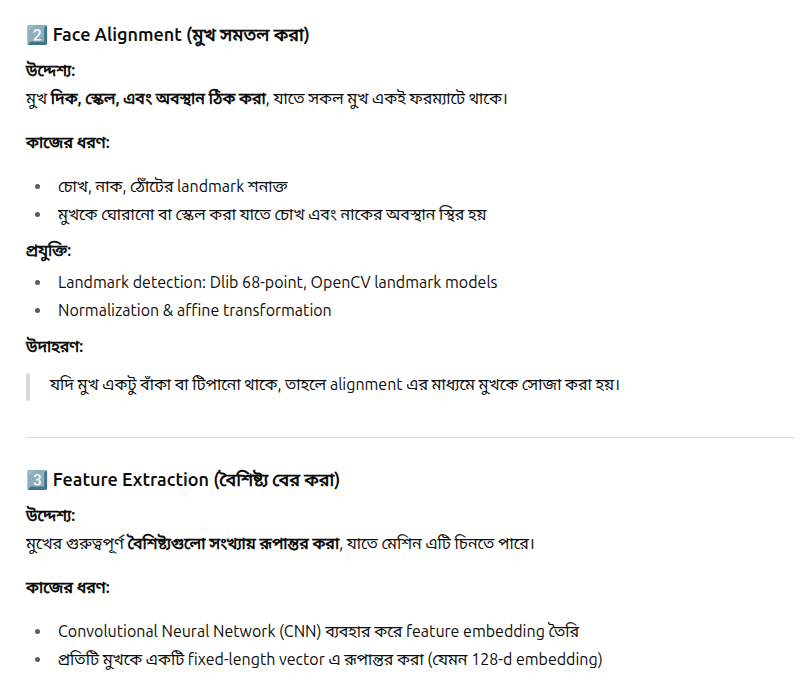

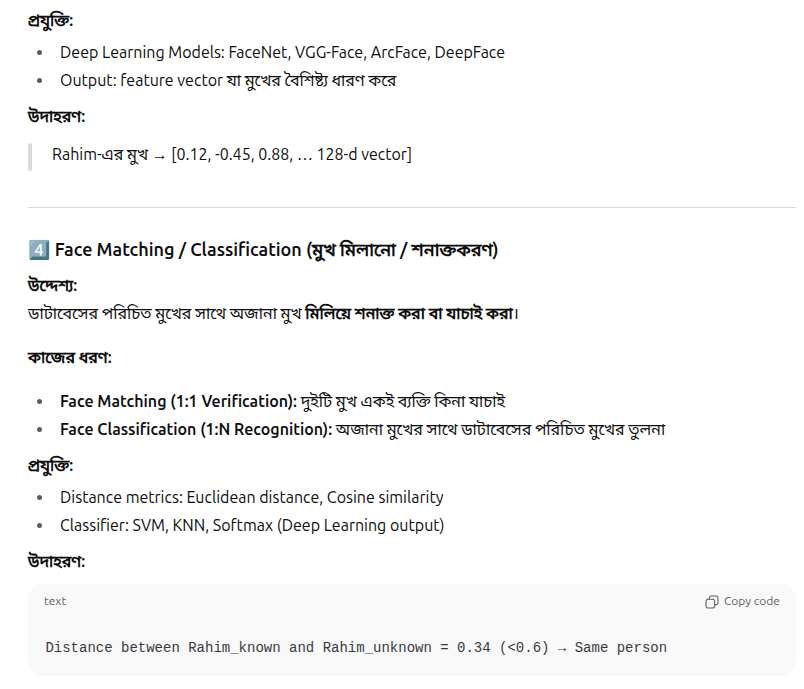

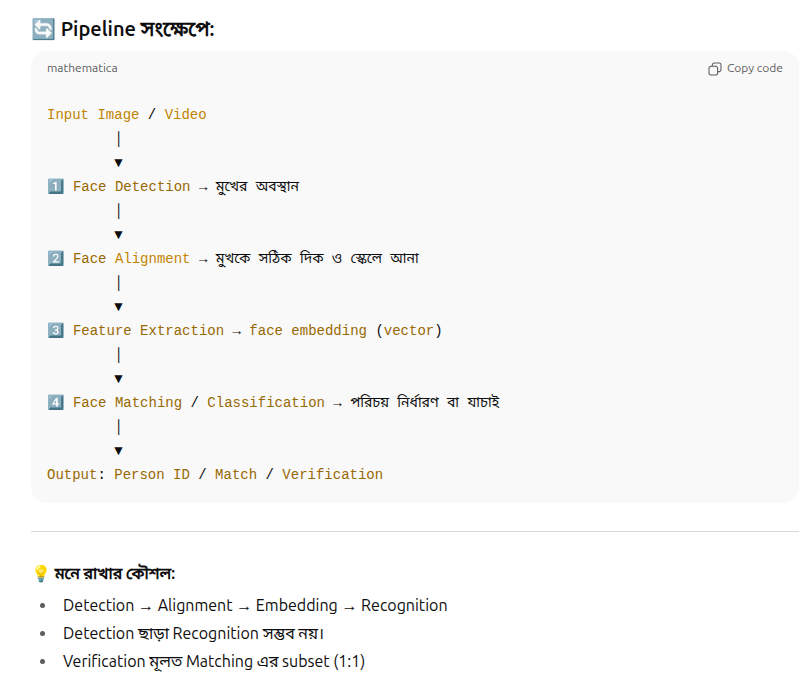

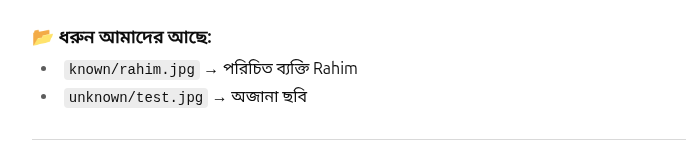

In [14]:
import face_recognition
import cv2
import numpy as np


# 1. Load known face
known_image = face_recognition.load_image_file("../dataset/train/deligt/5.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]
known_name = "De Ligt"


# 2. Load unknown image
unknown_image = face_recognition.load_image_file("../dataset/train/deligt/3.jpg")


# 3. Face Detection
face_locations = face_recognition.face_locations(unknown_image)
print(f"মোট মুখ পাওয়া গেছে: {len(face_locations)}")
print("মুখের অবস্থান:", face_locations)


# 4. Face Feature Extraction (Encoding)
unknown_encodings = face_recognition.face_encodings(unknown_image, face_locations)


# 5. Face Matching / Recognition
for unknown_encoding, location in zip(unknown_encodings, face_locations):
    
    # Recognition: 1:N match
    results = face_recognition.compare_faces([known_encoding], unknown_encoding)
    
    # Verification: 1:1 distance
    distance = face_recognition.face_distance([known_encoding], unknown_encoding)[0]
    
    # Print results
    print("\nমুখের অবস্থান:", location)
    print("Recognition Result:", known_name if results[0] else "Unknown")
    print(f"Verification Distance: {distance:.2f}")
    if distance < 0.6:
        print("Verification: ✅ Match (Same Person)")
    else:
        print("Verification: ❌ Not Match (Different Person)")


# 6. Visualization with OpenCV
image = cv2.cvtColor(unknown_image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left), unknown_encoding in zip(face_locations, unknown_encodings):
    cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)
    label = known_name if face_recognition.compare_faces([known_encoding], unknown_encoding)[0] else "Unknown"
    cv2.putText(image, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

cv2.imshow("Face Recognition Pipeline", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

মোট মুখ পাওয়া গেছে: 1
মুখের অবস্থান: [(62, 85, 98, 49)]

মুখের অবস্থান: (62, 85, 98, 49)
Recognition Result: De Ligt
Verification Distance: 0.55
Verification: ✅ Match (Same Person)


# 6. Face Recognition Workflow Overview

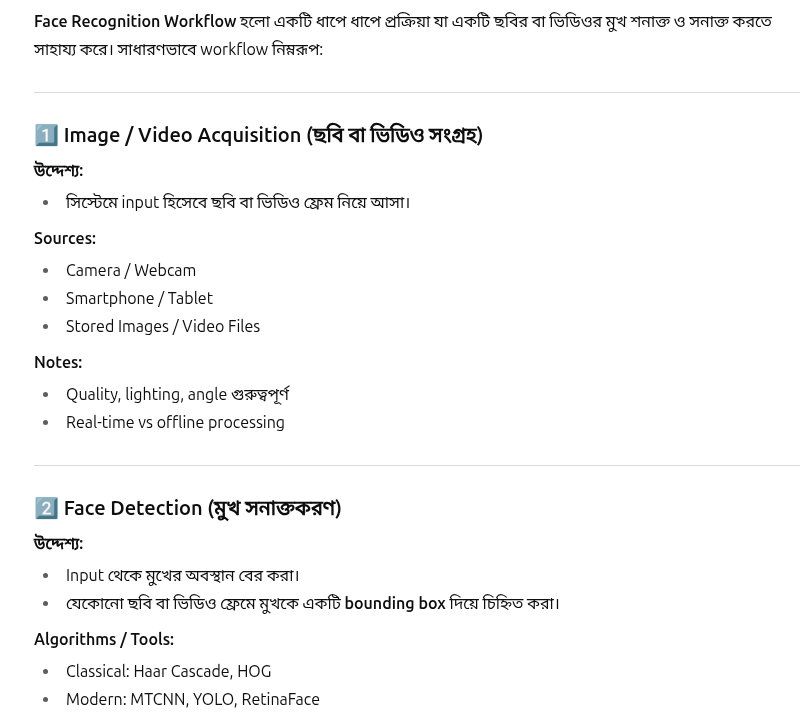

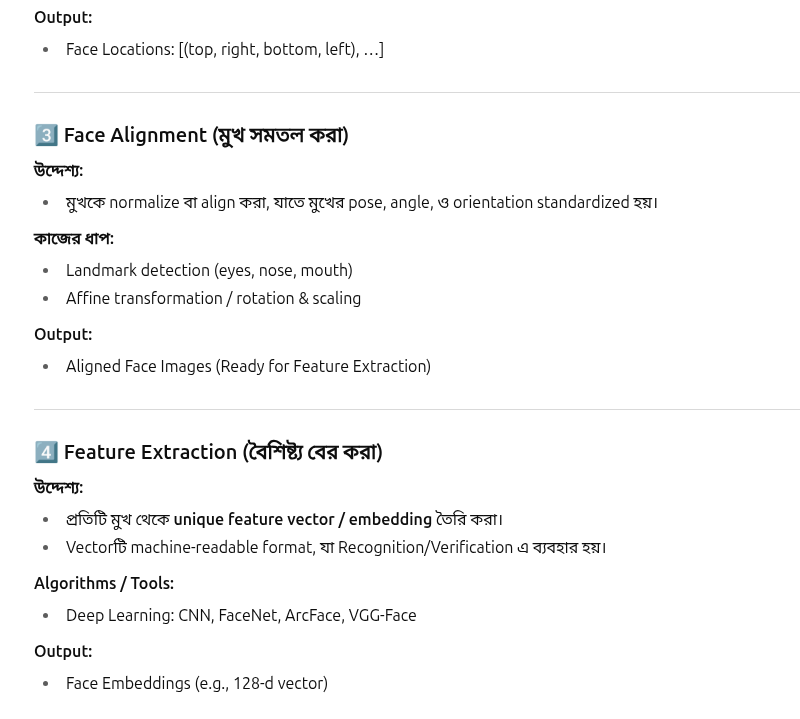

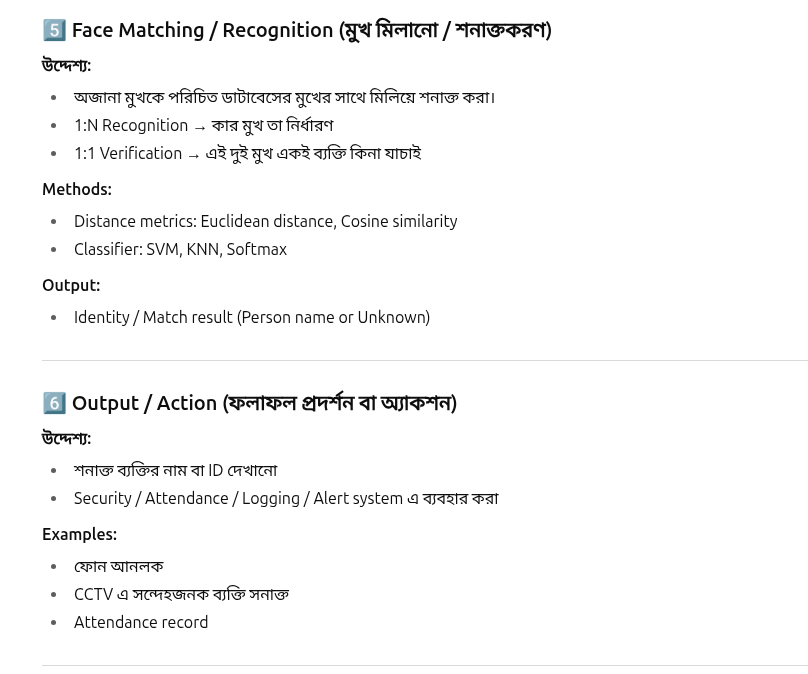

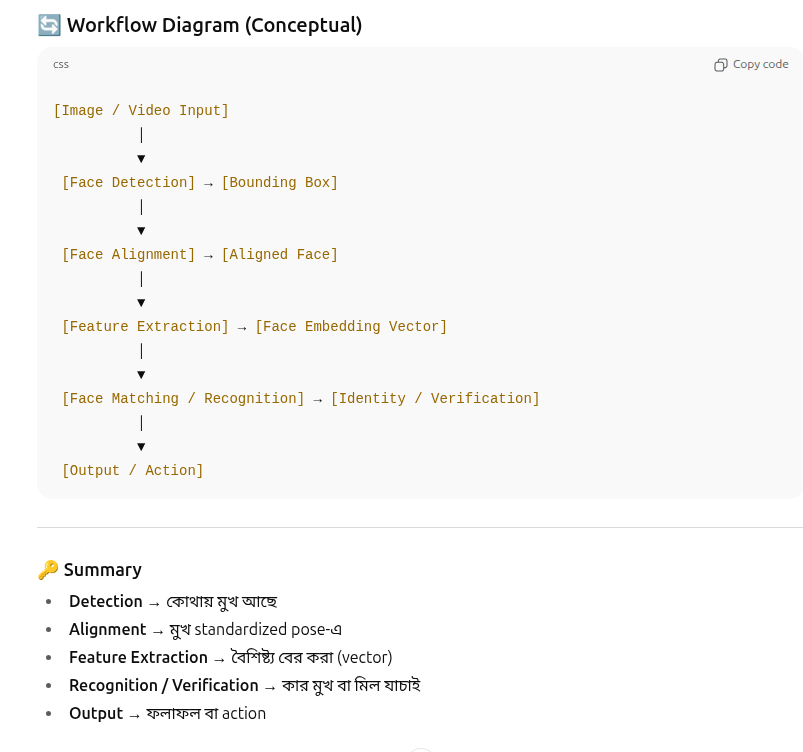

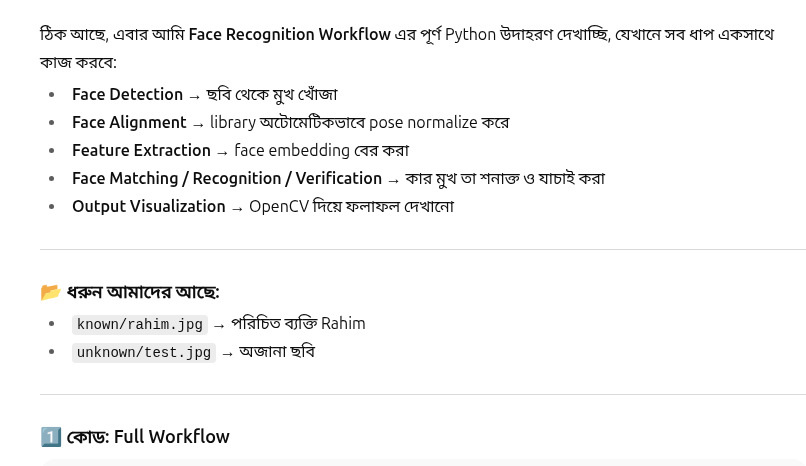

In [18]:
import face_recognition
import cv2
import numpy as np


# 1. Load known face
known_image = face_recognition.load_image_file("../dataset/train/ozil/6.jpg")
known_encoding = face_recognition.face_encodings(known_image)[0]
known_name = "Ozil"


# 2. Load unknown image
unknown_image = face_recognition.load_image_file("../dataset/train/ozil/3.jpg")


# 3. Face Detection
face_locations = face_recognition.face_locations(unknown_image)
print(f"মোট মুখ পাওয়া গেছে: {len(face_locations)}")
print("মুখের অবস্থান:", face_locations)


# 4. Face Feature Extraction (Encoding)
unknown_encodings = face_recognition.face_encodings(unknown_image, face_locations)


# 5. Face Matching / Recognition
for unknown_encoding, location in zip(unknown_encodings, face_locations):
    
    # Recognition: 1:N match
    results = face_recognition.compare_faces([known_encoding], unknown_encoding)
    
    # Verification: 1:1 distance
    distance = face_recognition.face_distance([known_encoding], unknown_encoding)[0]
    
    # Print results
    print("\nমুখের অবস্থান:", location)
    print("Recognition Result:", known_name if results[0] else "Unknown")
    print(f"Verification Distance: {distance:.2f}")
    if distance < 0.6:
        print("Verification: ✅ Match (Same Person)")
    else:
        print("Verification: ❌ Not Match (Different Person)")


# 6. Visualization with OpenCV
image = cv2.cvtColor(unknown_image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left), unknown_encoding in zip(face_locations, unknown_encodings):
    cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)
    label = known_name if face_recognition.compare_faces([known_encoding], unknown_encoding)[0] else "Unknown"
    cv2.putText(image, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

cv2.imshow("Face Recognition Pipeline", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

মোট মুখ পাওয়া গেছে: 1
মুখের অবস্থান: [(118, 132, 161, 88)]

মুখের অবস্থান: (118, 132, 161, 88)
Recognition Result: Ozil
Verification Distance: 0.44
Verification: ✅ Match (Same Person)


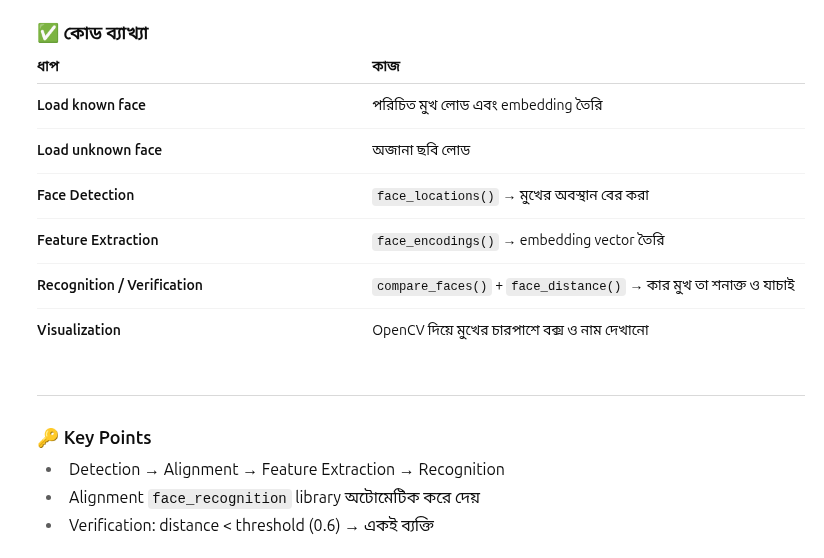